In [9]:
from typing import Dict, List, Any, Tuple
import numpy as np
from numpy.typing import NDArray
import pandas as pd

from model_ranking import (
    get_summary_results, 
    results_to_arrays,
    per_source_model_results,
    cmb_consistency_score_weighted_average,
    per_target_consis_result_type,
    per_target_performance_result_type,
)
from model_ranking import plot_alpha_sweep_specific_norm
from model_ranking import (
    calculate_correlation_statistics
)

In [11]:
NA_UNet_source_models = {
    "PNAS": "p_model_NA1",
    "Ovules": "ov_model_NA1",
}
Res_source_models = {
    "FlyWing": "fw_model_Res2",
    "Ovules": "ov_model_Res1",
    "PNAS": "p_model_Res1",
}

Unetr_source_models = {
    "FlyWing": "fw_model_Unetr2",
    "Ovules": "ov_model_Unetr1",
    "PNAS": "p_model_Unetr1",
}
Unet_source_models={
    "FlyWing": "fw_model_Unet2",
    "Ovules": "ov_model_UNet1",
    "PNAS": "p_model_UNet1",
}
# consis_keys={
#     "FlyWing": "AdaRandError_consis",
#     "Ovules": "AdaRandError_consis",
# }
consis_keys={
    "FlyWing": "weighted_AdaRandError_consis",
    "Ovules": "weighted_AdaRandError_consis",
}
# consis_keys_bckg = {
#     "FlyWing": "AdaRandError_consis_bckg",
#     "Ovules": "AdaRandError_consis_bckg",
#     "PNAS": "AdaRandError_consis_bckg",
# }
result_folders={
    "FlyWing": "P_fullslice",
    "Ovules": "P_fullslice",
    "PNAS": "P_full",
}

per_target_norms: Dict[str, List[Tuple[float,float]]] = {
    "FlyWing": [(5.0, 95.0)],
    "Ovules": [(5.0, 95.0)],
    "PNAS": [(5.0, 95.0)],
}

perf_key = "MAP_05_095"
approach="feature_perturbation_consistency"
base_result_path = "/g/kreshuk/talks/consistency_results/Instance_segmentation/Cells"

In [12]:
summary_results_postfix = "_full"
selected_augmentations = {
    "none": [""],
    "DO": ["a0001", "a0005", "a001", "a002", "a003", "a004", "a005", "a01"],
}
#targets = ["FlyWing", "Ovules", "PNAS"]
#targets = ["FlyWing"]
targets = ["FlyWing", "Ovules"]
#targets = ["Ovules"]
#source_model_types = [NA_UNet_source_models, Res_source_models, Unet_source_models, Unetr_source_models]
source_model_types = [Unet_source_models, NA_UNet_source_models,  Res_source_models]

In [13]:
per_target_forg_consistency: per_target_consis_result_type= {}
per_target_forg_performance: per_target_performance_result_type = {}
sources = ["FlyWing", "Ovules", "PNAS"]
for i, target in enumerate(targets):
        
    per_source_forg_consistency = {}
    per_source_forg_performance = {}

    for model_type in source_model_types:
        if "NA" in model_type["PNAS"]:
            sources = ["Ovules", "PNAS"]
        
        else:
            sources = ["FlyWing", "Ovules", "PNAS"]
            
        consis_str, _, NA_perf = get_summary_results(
            source_data=sources,
            target_data=[target],
            source_models = model_type,
            selected_augmentations=selected_augmentations,
            selected_norms=per_target_norms,
            consis_keys=consis_keys,
            perf_key=perf_key,
            per_target_norms=True,
            result_folders=result_folders,
            approach=approach,
            #consis_postfix="median",
            consis_postfix=None,
            perf_postfix="median",
            summary_results_postfix=summary_results_postfix,
            base_seg_dir=base_result_path,
        )
        per_source_forg_consistency.update(
            per_source_model_results(
                consis_str, 
                source_models=model_type, 
            ))
        per_source_forg_performance.update(
            per_source_model_results(
                NA_perf, 
                source_models=model_type,
            ))
    
    per_target_forg_consistency[target] = per_source_forg_consistency
    per_target_forg_performance[target] = per_source_forg_performance


Source: FlyWing


100%|██████████| 1/1 [00:00<00:00,  5.90it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00,  7.31it/s]


Source: PNAS


...

100%|██████████| 1/1 [00:00<00:00,  7.06it/s]


Source: Ovules


100%|██████████| 1/1 [00:00<00:00, 14.66it/s]


Source: PNAS


100%|██████████| 1/1 [00:00<00:00, 13.34it/s]


In [14]:
per_target_forg_consistency

{'FlyWing': {'fw_model_Unet2': {'norm_50_950': {'DO': array([0.00029347, 0.00037985, 0.00052163, 0.00102991, 0.00098046,
           0.00139358, 0.0015128 , 0.0017802 ])}},
  'ov_model_UNet1': {'norm_50_950': {'DO': array([0.00388983, 0.00739226, 0.01210737, 0.0216439 , 0.02387538,
           0.02803195, 0.02887374, 0.03284453])}},
  'p_model_UNet1': {'norm_50_950': {'DO': array([0.00065281, 0.00119928, 0.00157416, 0.00276613, 0.00332047,
           0.00366262, 0.00414149, 0.00699092])}},
  'ov_model_NA1': {'norm_50_950': {'DO': array([0.13669102, 0.19068426, 0.21243765, 0.29643721, 0.35748908,
           0.45388104, 0.54281544, 0.88064102])}},
  'p_model_NA1': {'norm_50_950': {'DO': array([0.0007868 , 0.0019807 , 0.00243571, 0.00363091, 0.00418496,
           0.00482712, 0.00559602, 0.00930026])}},
  'fw_model_Res2': {'norm_50_950': {'DO': array([7.65149780e-05, 1.88514461e-04, 2.94282317e-04, 4.44647168e-04,
           5.31928442e-04, 6.30242301e-04, 7.07574916e-04, 8.84248332e-04])}}

# Fullslice

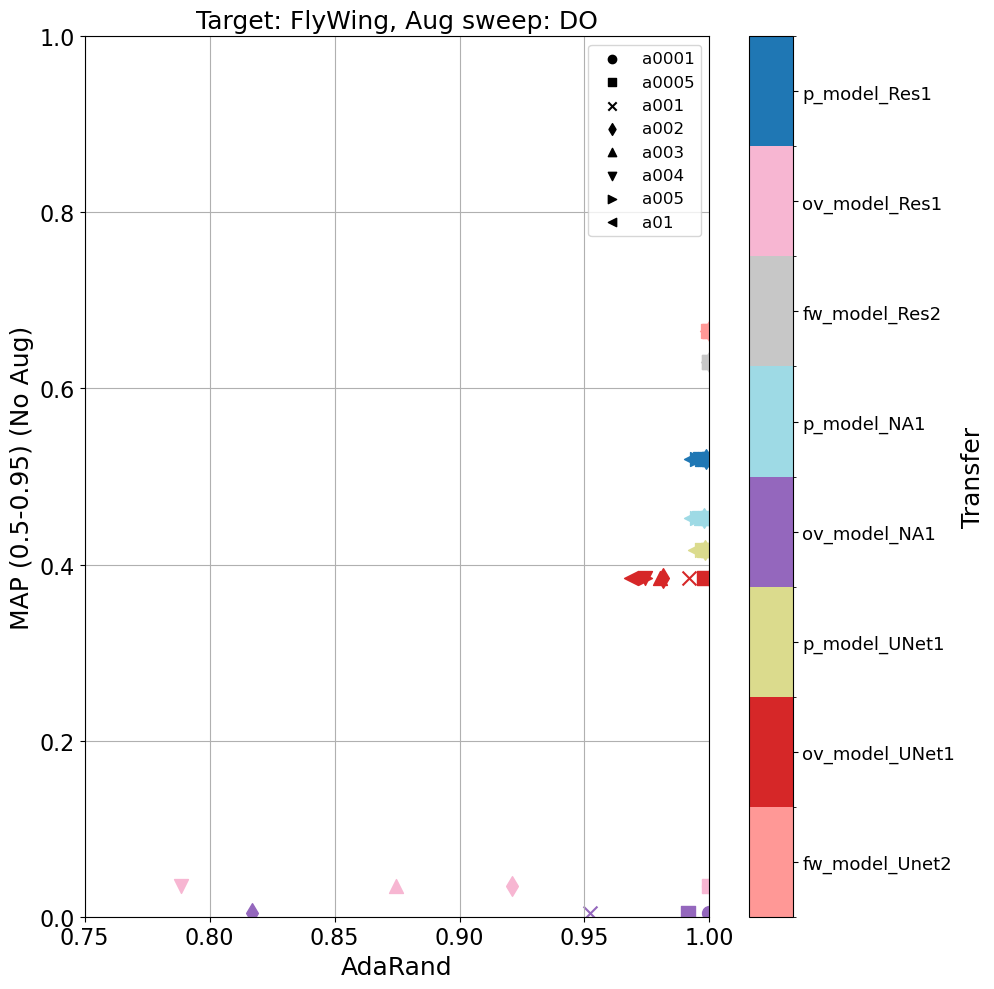

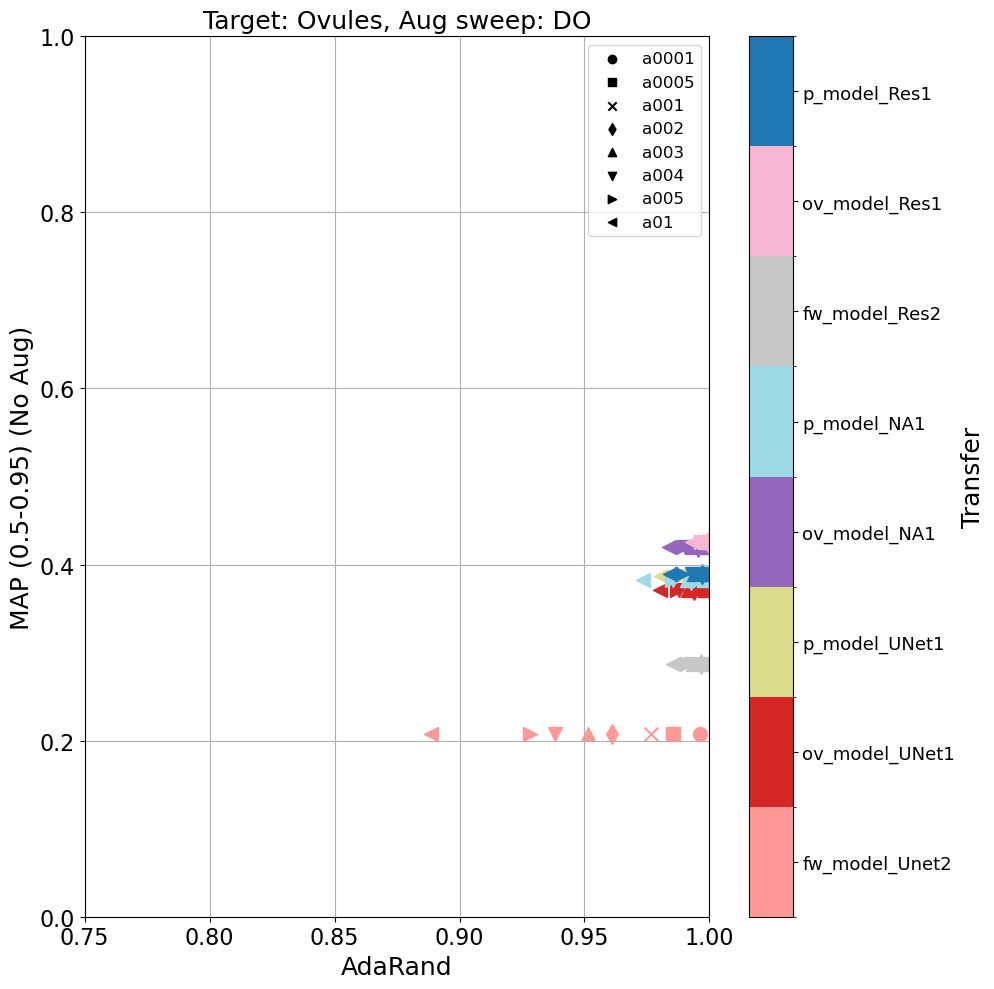

In [8]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.75, 1),
        n_rows=1,
        n_cols = 1,
    )

# Fullslice weighted Average

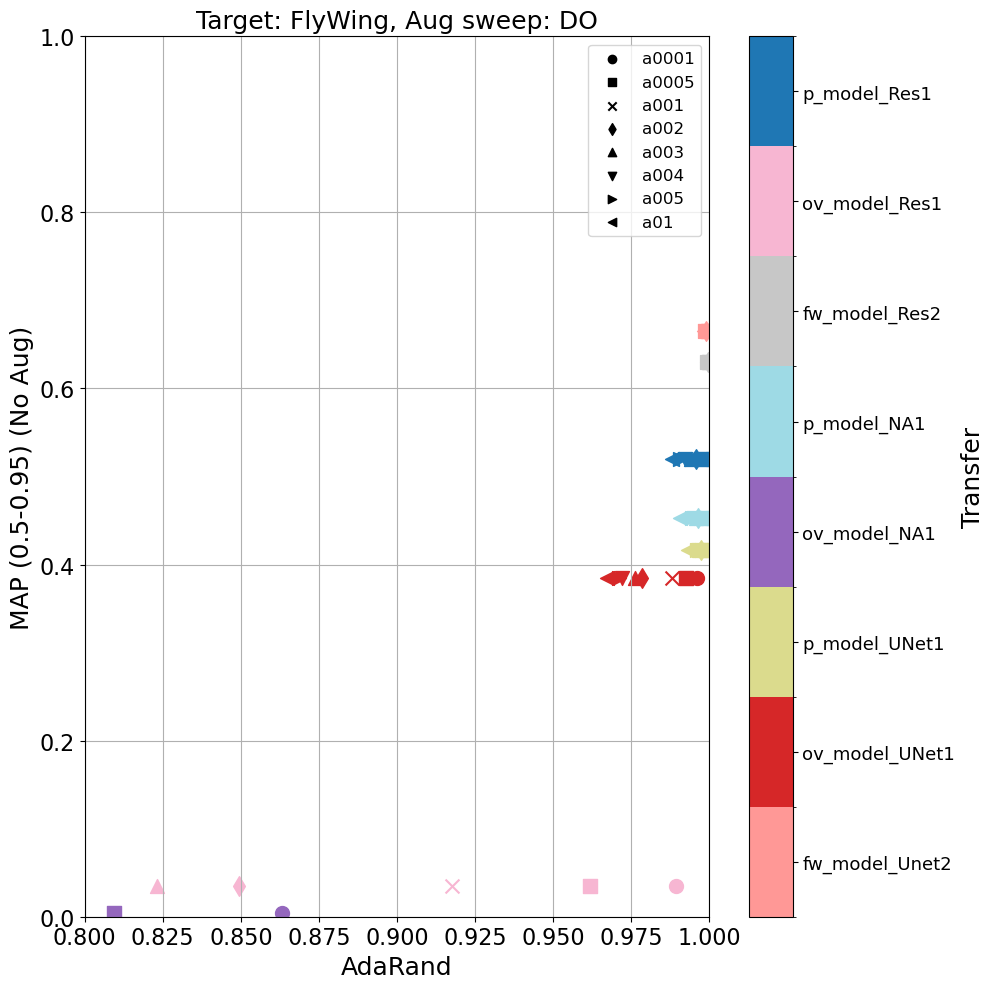

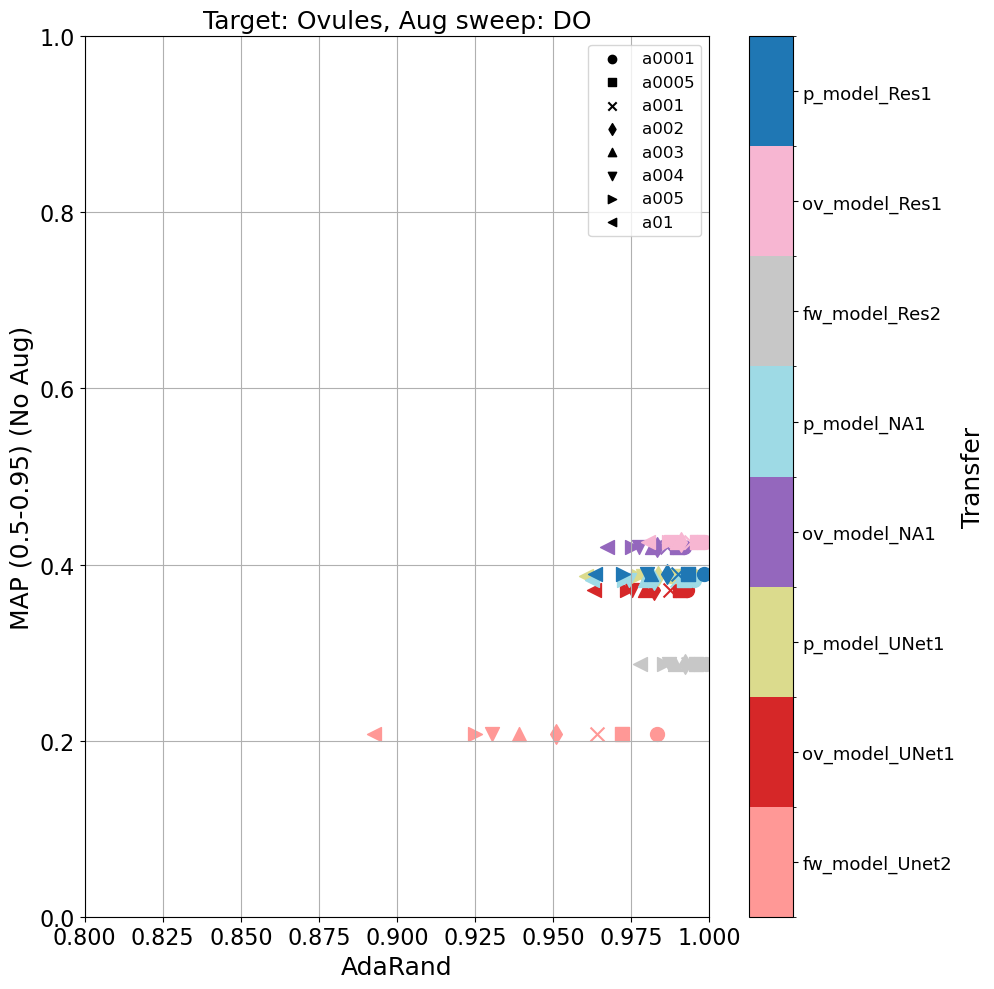

In [17]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["DO"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0.8, 1),
        n_rows=1,
        n_cols = 1,
    )

# Fullsize

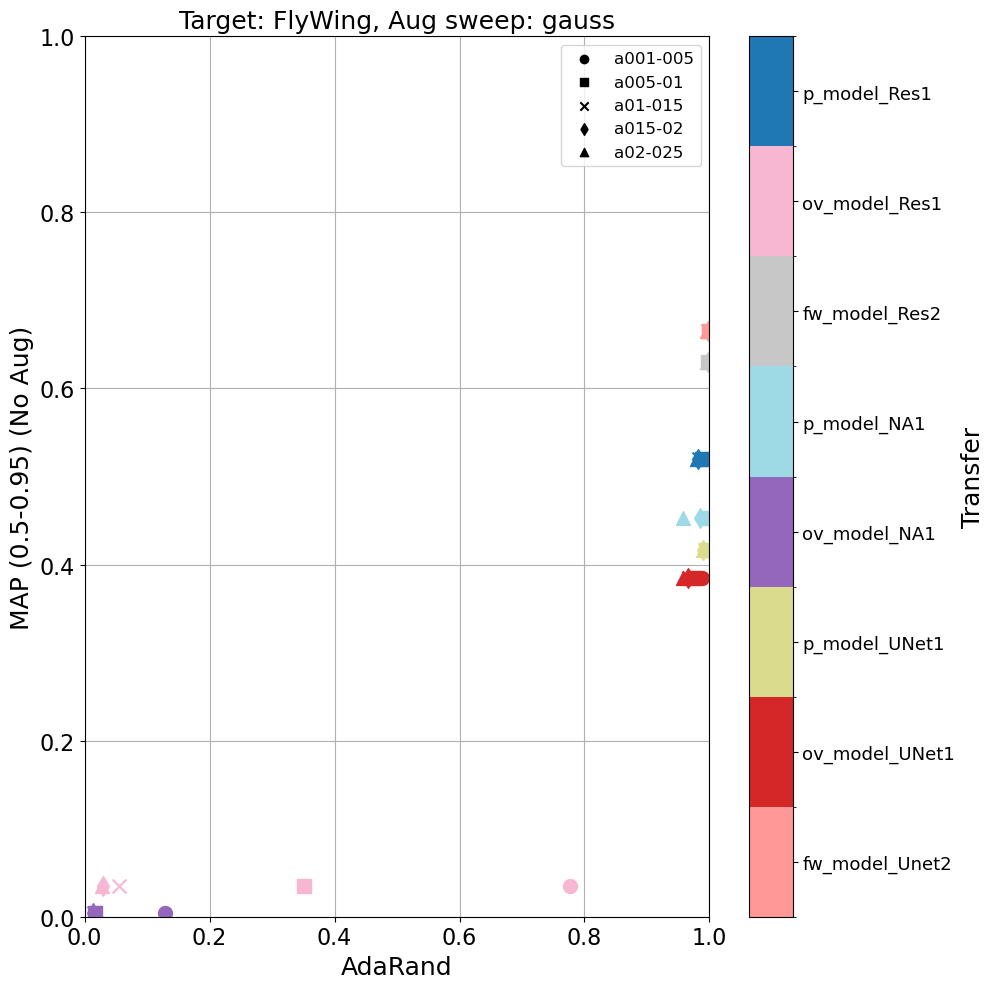

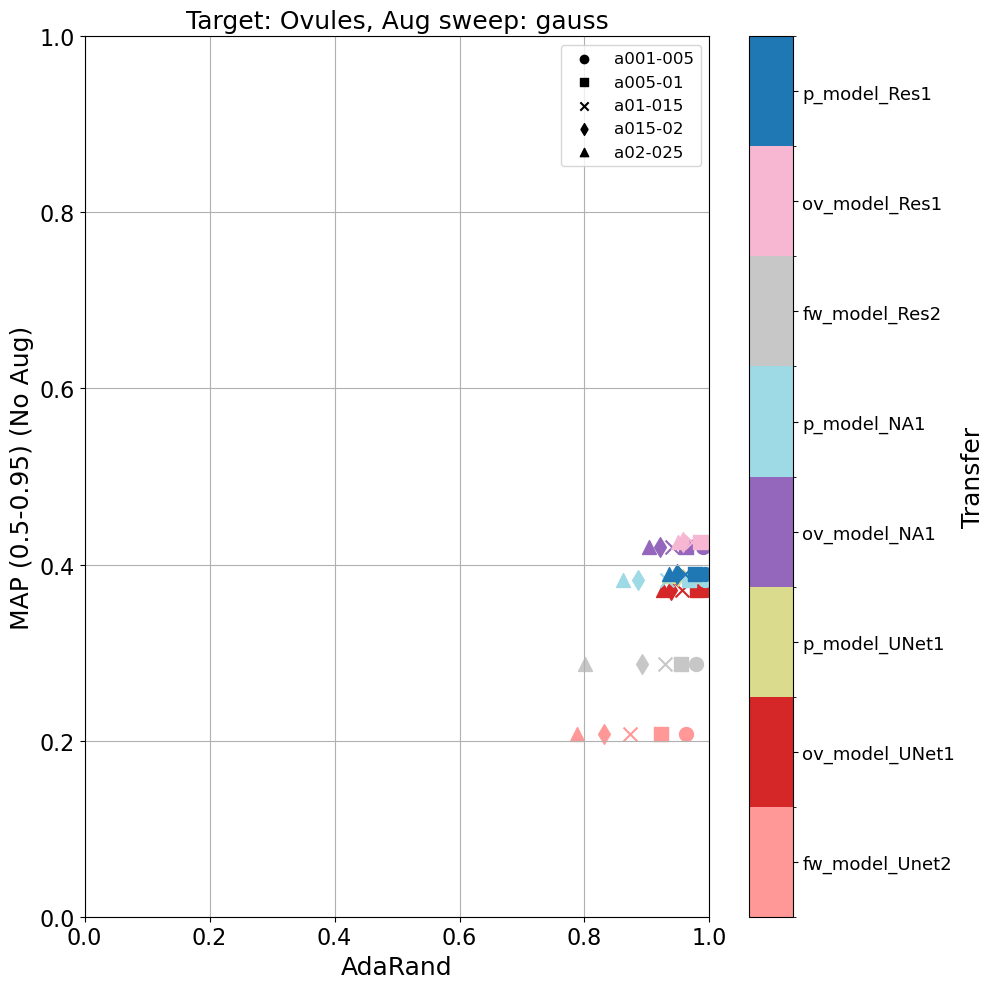

In [16]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

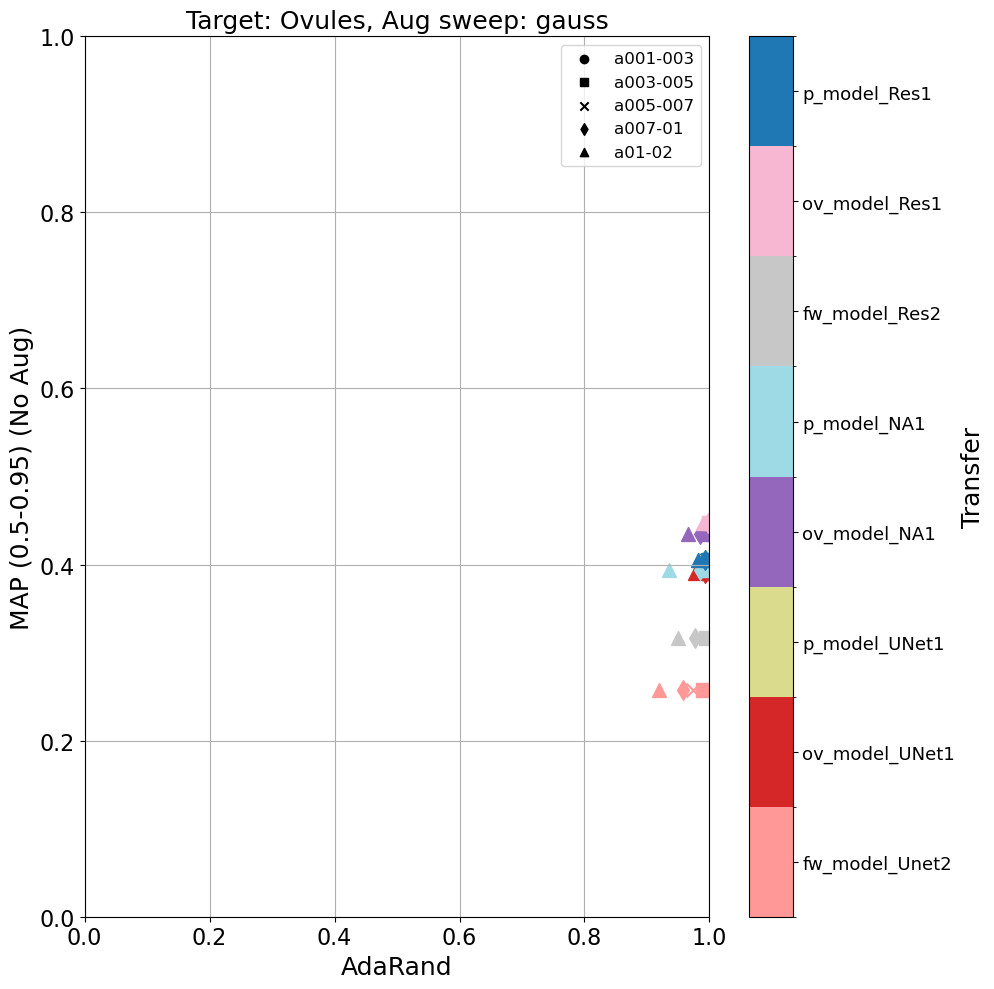

In [11]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

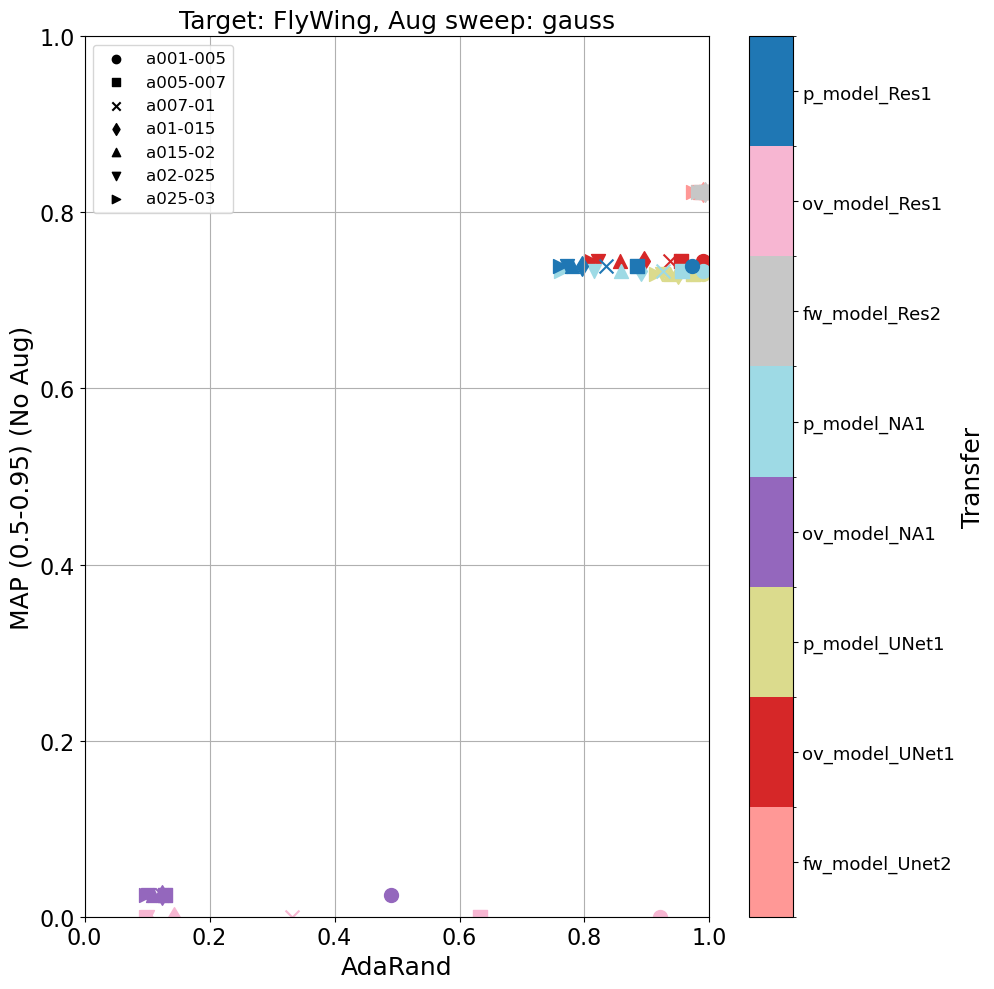

In [6]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

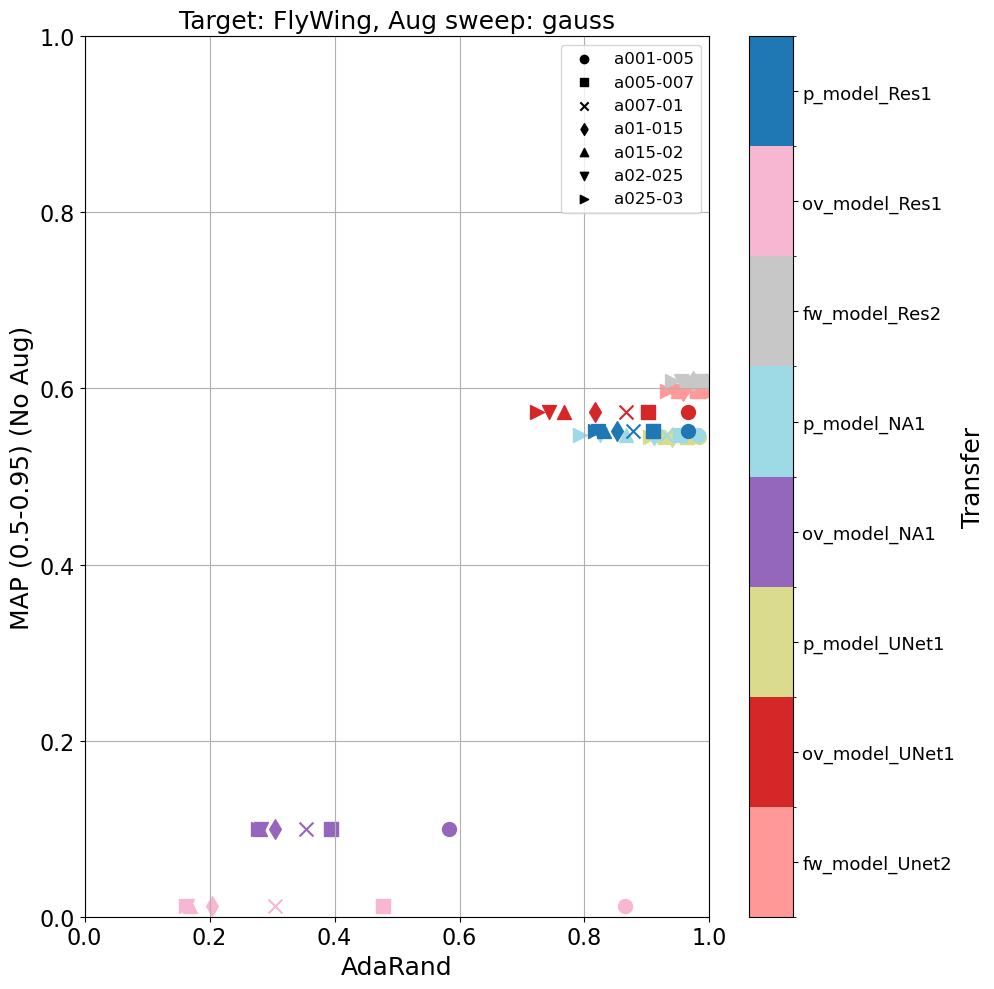

In [38]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )

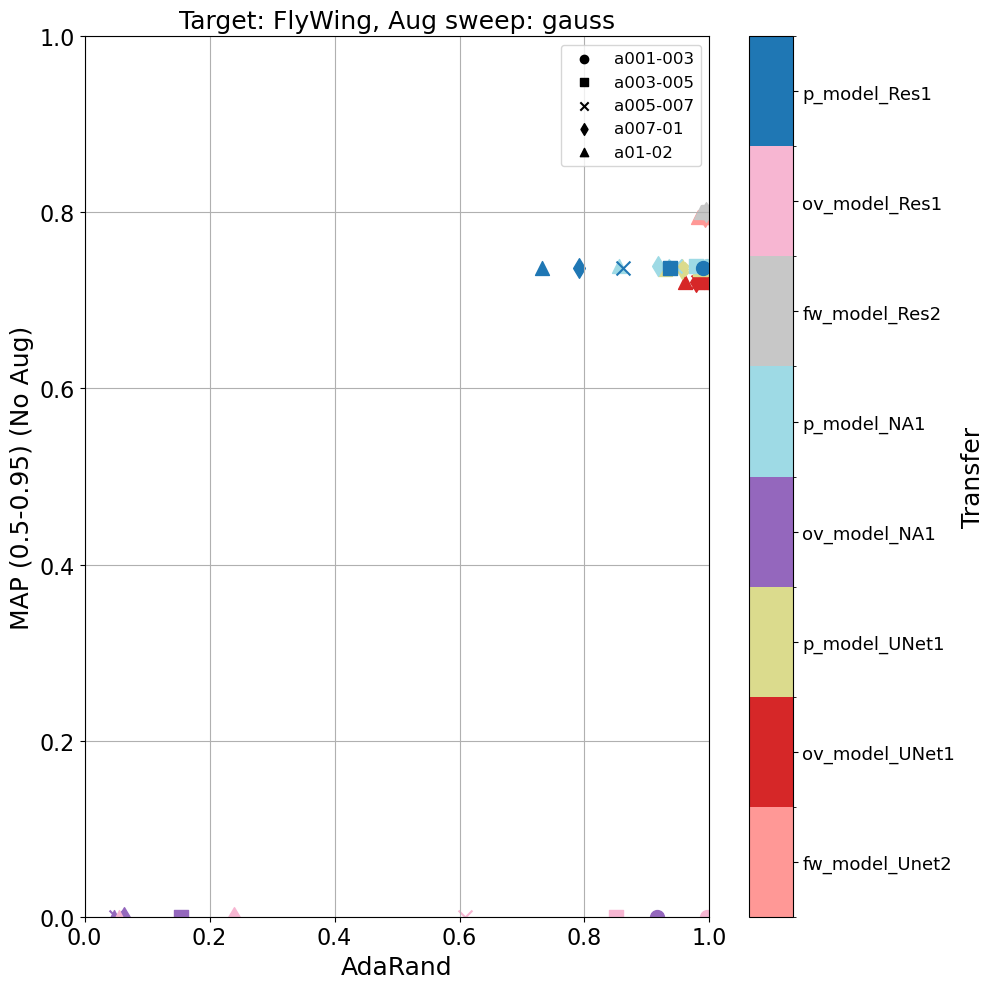

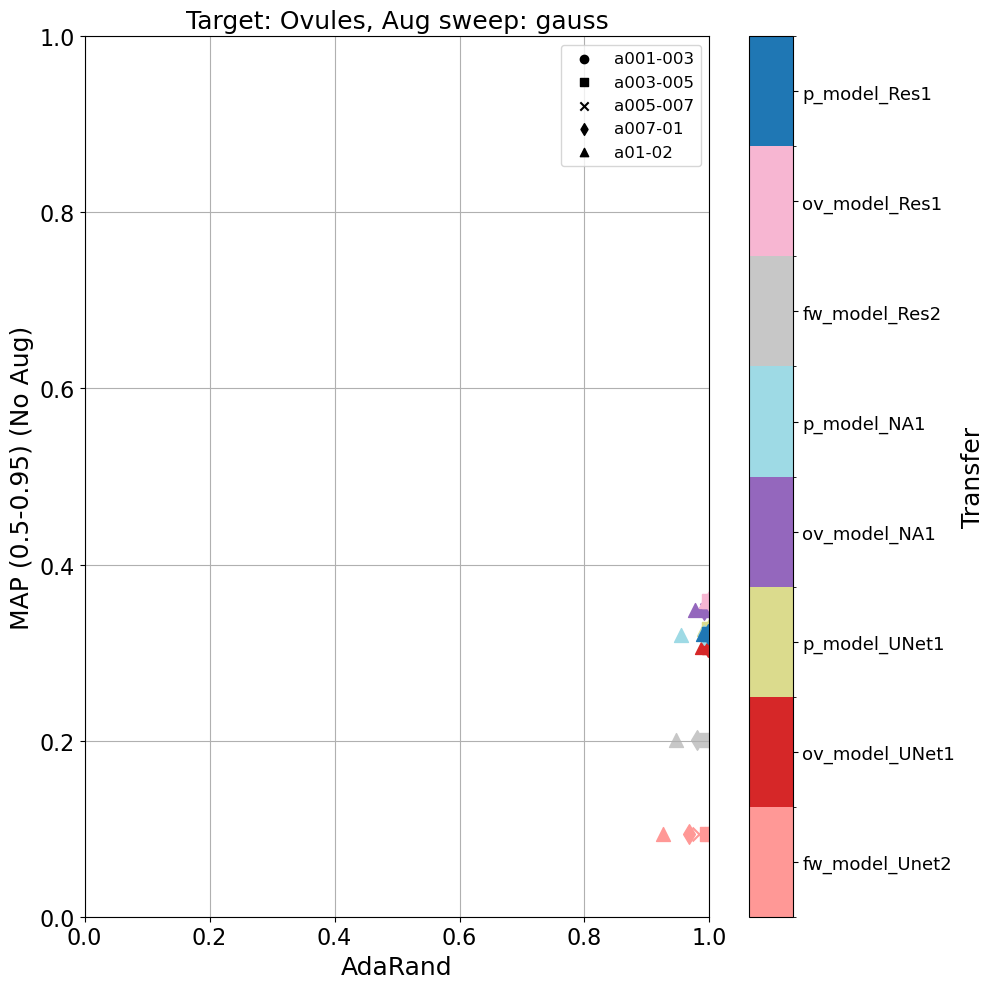

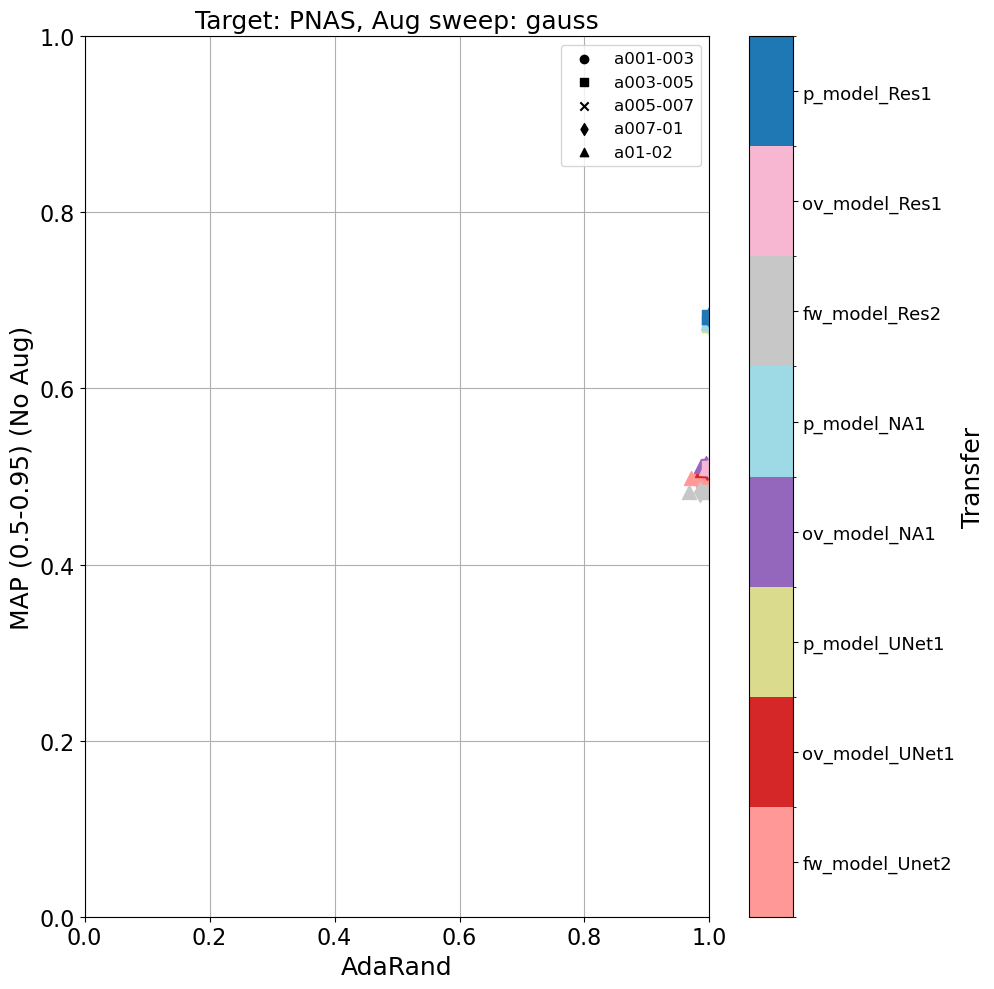

In [42]:
for target in targets:
    plot_alpha_sweep_specific_norm(
        per_target_forg_consistency[target],
        per_target_forg_performance[target],
        augs=["gauss"],
        select_alphas=selected_augmentations,
        select_norms=per_target_norms,
        consistency_metric_name="AdaRand",
        invert_consis_metric= True,
        invert_perf_metric=False,
        transfer_metric_name="MAP (0.5-0.95)",
        pos_correlation_line=False,
        per_transfer_norms=False,
        single_target=target,
        xlim=(0, 1),
        n_rows=1,
        n_cols = 1,
    )